In [1]:
import numpy as np
import pandas as pd
import torch


In [1]:
import time
from stable_baselines3 import DQN

# Train on CPU
# start_cpu = time.time()
# model_cpu = DQN('MlpPolicy', 'CartPole-v1', verbose=1, device='cpu')
# model_cpu.learn(total_timesteps=10000)
# end_cpu = time.time()
# print(f"CPU Training Time: {end_cpu - start_cpu:.2f} seconds")

# Train on GPU
start_gpu = time.time()
model_gpu = DQN('MlpPolicy', 'CartPole-v1', verbose=1, device='mps')  # Use 'cuda' for NVIDIA GPUs
model_gpu.learn(total_timesteps=10000)
end_gpu = time.time()
print(f"GPU Training Time: {end_gpu - start_gpu:.2f} seconds")


Using mps device
Creating environment from the given name 'CartPole-v1'
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.2     |
|    ep_rew_mean      | 16.2     |
|    exploration_rate | 0.938    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 18955    |
|    time_elapsed     | 0        |
|    total_timesteps  | 65       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18.9     |
|    ep_rew_mean      | 18.9     |
|    exploration_rate | 0.857    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 44       |
|    time_elapsed     | 3        |
|    total_timesteps  | 151      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.502    |
|    n_upda

KeyboardInterrupt: 

## First Experiment -- without SVD

#### Setup

In [61]:
# Initialize parameters
num_users = 6  # |U|
num_items = 12  # |I|
num_days = 200  # |T|
K = 10  # maximum days of data visibility
lambda_val = 0.5  # weighting factor for utility and privacy
target_utility = 25
privacy_constant = 1

#### Functions

In [62]:
def apply_along_axis(x,function,axis,z=None):
    if isinstance(x,np.ndarray):
        y = torch.from_numpy(x)
    else:
        y=x
    if z is not None:
        res = torch.stack([function(x_i,z[i]) for i, x_i in enumerate(torch.unbind(y, dim=axis), 0)], dim=axis)
    else:
        res = torch.stack([function(x_i) for i, x_i in enumerate(torch.unbind(y, dim=axis), 0)], dim=axis)
    return res

# Define utility and privacy functions
def utility_function(x_u, X_t):
    # Utility is the dot product of the user's data with all other users' data
    return np.mean([np.dot(x_u, X_t[v]) for v in range(num_users)])

def privacy_function(x_u):
    # Privacy risk is inversely proportional to the number of items shared
    #return privacy_constant / np.sum(x_u > 0)
    #return privacy_constant*np.exp(-np.sum(x_u>0))
    return privacy_constant*(np.sum(x_u==0))

# Reward function combining utility and privacy
def compute_reward(x_u, X_t):
    f_u = utility_function(x_u, X_t)
    g_u = privacy_function(x_u)
    return lambda_val * f_u + (1 - lambda_val) * g_u

# Action logic based on strategy
def take_action(u, current_k, state_u, target_utility, X_t):
    #current_reward = compute_reward(state_u, X_t)
    utility = utility_function(state_u,X_t)
    #privacy_risk = privacy_function(state_u)
    if utility < target_utility and current_k < K:
        return 'add'
    elif utility >= target_utility and current_k > 1:
        return 'subtract'
    else:
        return 'wait'

# Update history
def update_history(state_history,new_data):
    state_history = np.concatenate((state_history[1:,:,:],new_data[np.newaxis,:,:]),axis=0)
    return state_history

def generate_new():
    array = np.zeros((num_users, num_items), dtype=int)
    num_entries = num_users
    indices = np.random.choice(num_users * num_items, size=num_entries, replace=False)
    array.flat[indices] = np.random.randint(1, 6, size=num_entries)
    return array

def latest_nonzero(vector):
    nonzero_values = vector[vector != 0]  # Get nonzero values in the column
    if len(nonzero_values) > 0:
        return nonzero_values[-1]  # Take the latest (last) nonzero value
    else:
        return torch.tensor(0)  # No nonzero value, so set to 0

def filtering(state_history_u,current_ks_u):
    temp = state_history_u[-current_ks_u:,:]
    #print(temp)
    return apply_along_axis(temp,latest_nonzero,axis=-1)

def current_state(state_history,current_ks):
    return torch.transpose(apply_along_axis(state_history,filtering,axis=1,z=current_ks),0,1)

def update_states(state_history,current_ks):
    new_data = generate_new()
    state_history = update_history(state_history,new_data)
    current_states = current_state(state_history,current_ks)
    return state_history,current_states.cpu().numpy()

#### Simulations

In [ ]:
# Initialize the states x^0_u for each user with random preferences (ratings)
results = []
# Each user has a vector of ratings between 1 and 5 for 10 items
state_history = np.array([generate_new() for i in range(3)])
#states = np.random.randint(1, 6, size=(num_users, num_items))  # initial data for day 0
current_ks = np.random.randint(1, K+1, size=num_users)  # initial K values for each user
states = current_state(state_history,current_ks).cpu().numpy()
target_utilities = np.random.uniform(1, target_utility, size=num_users)  # random target utilities for each user

# Simulation over 100 days
for day in range(1, num_days+1):
    #print(f"Day {day}")
    for u in range(num_users):
        X_t = states  # stacked user states at day t
        action = take_action(u, current_ks[u], states[u], target_utilities[u], X_t)

        if action == 'add' and current_ks[u] < K:
            current_ks[u] += 1  # Increase K by 1
        elif action == 'subtract' and current_ks[u] > 1:
            current_ks[u] -= 1  # Decrease K by 1

    # Update the visible data for the user (only the last K days of data are visible)
    state_history,states = update_states(state_history,current_ks)

    # Print current K values and rewards for all users
    for u in range(num_users):
        utility = utility_function(states[u],states)
        privacy = privacy_function(states[u])
        reward = compute_reward(states[u], states)
        results.append({'day':day,'user':u,'utility':utility,'privacy':privacy,'reward':reward})
        print(states)
        #print(f"User {u}: K = {current_ks[u]}, utility = {utility:.2f}, privacy = {privacy:.2f},Reward = {reward:.2f}")
    #print("\n")


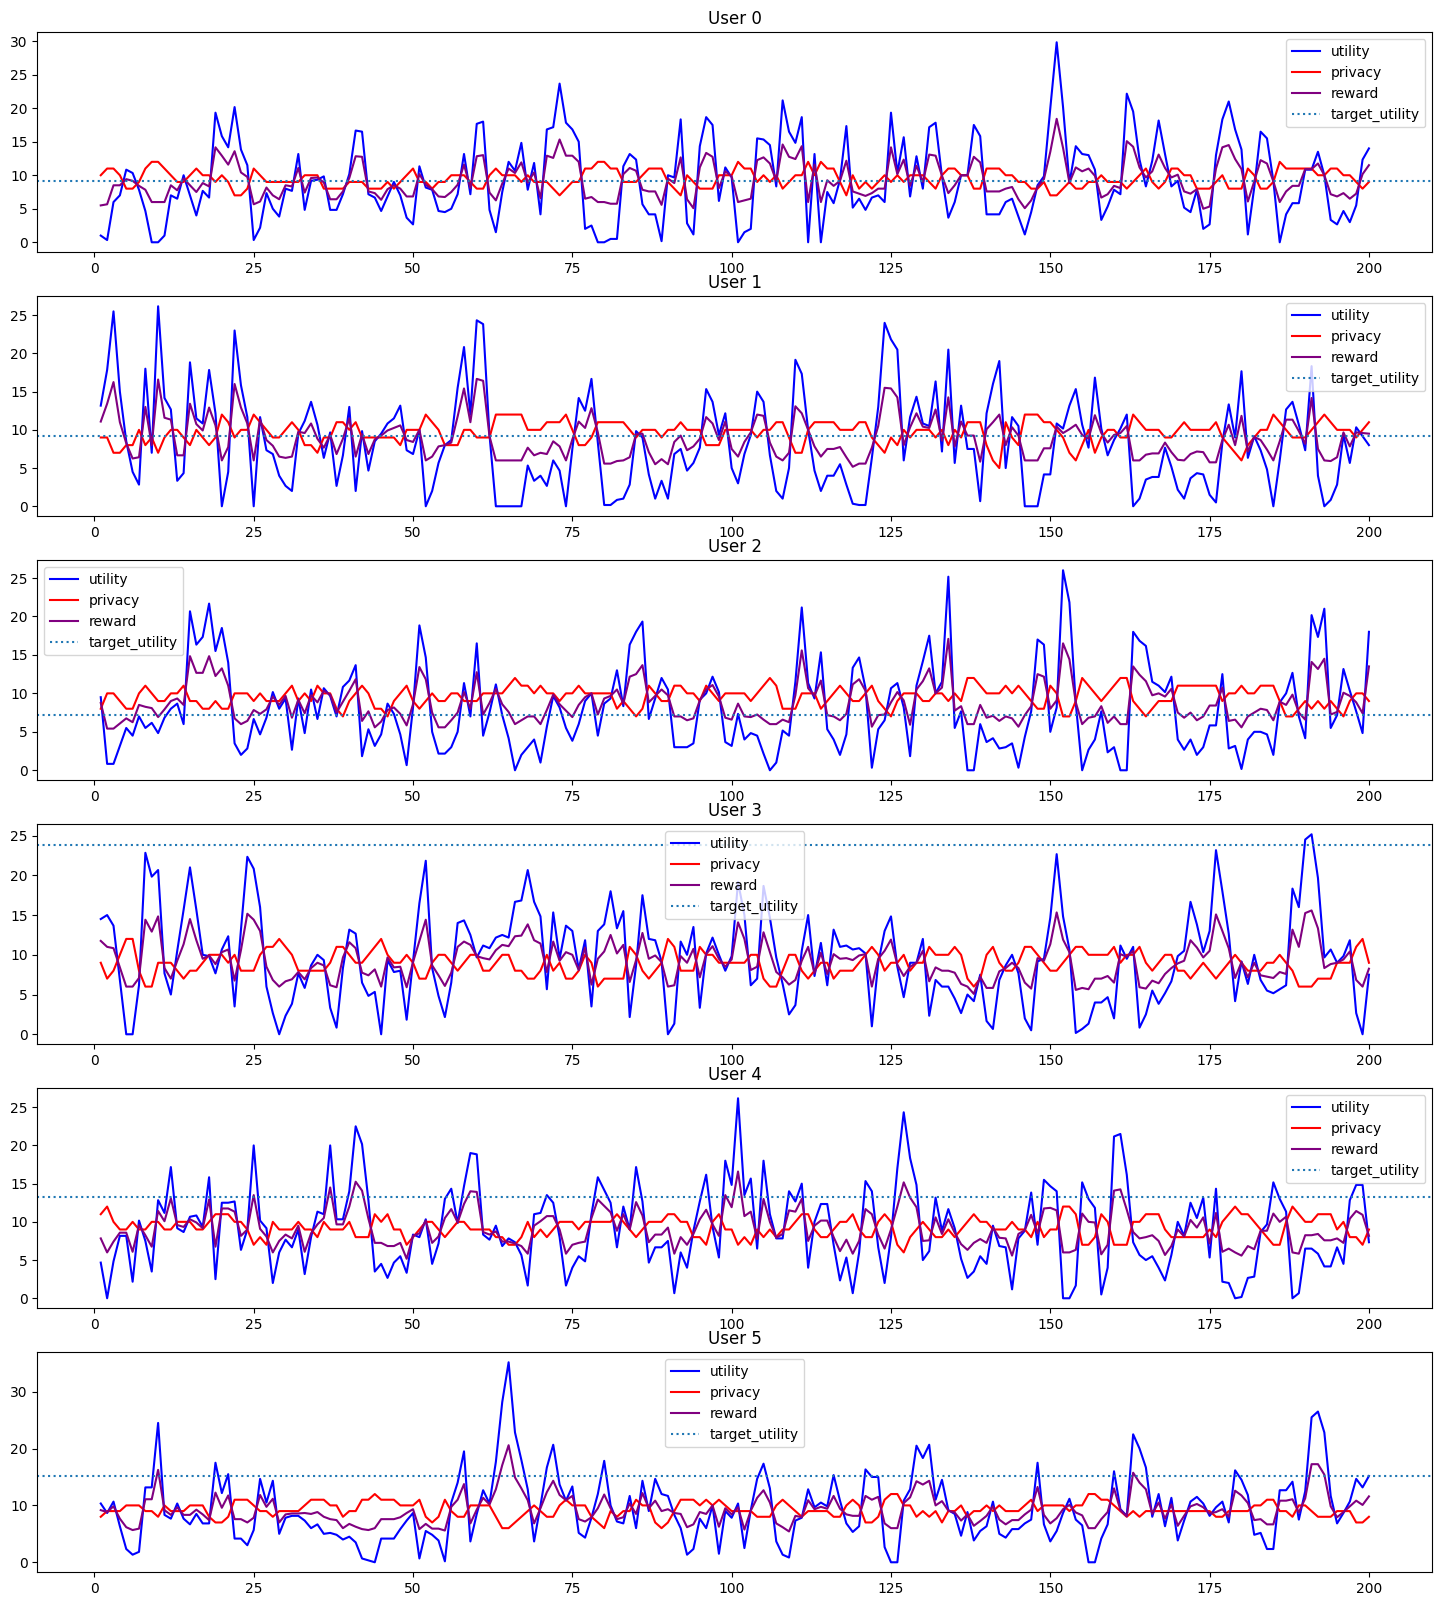

In [64]:
import matplotlib.pyplot as plt
df = pd.DataFrame(results)

fig, axes = plt.subplots(nrows=num_users, ncols=1, figsize=(num_users*3, 20))

for i in range(num_users):
    subset = df[df['user'] == i]
    ax = axes[i]
    ax.plot(subset['day'],subset['utility'],color='b',label='utility')
    ax.plot(subset['day'],subset['privacy'],color='r',label='privacy')
    ax.plot(subset['day'],subset['reward'],color='purple',label='reward')
    ax.axhline(y=target_utilities[i], linestyle='dotted', label=f'target_utility')
    ax.legend()
    ax.set_title(f'User {i}')

## With SVD and underlying preference

In [ ]:
# Initialize parameters
num_users = 6  # |U|
num_items = 12  # |I|
num_days = 200  # |T|
K = 10  # maximum days of data visibility
lambda_val = 0.5  # weighting factor for utility and privacy
target_utility = 25
privacy_constant = 1

In [ ]:
def apply_along_axis(x,function,axis,z=None):
    if isinstance(x,np.ndarray):
        y = torch.from_numpy(x)
    else:
        y=x
    if z is not None:
        res = torch.stack([function(x_i,z[i]) for i, x_i in enumerate(torch.unbind(y, dim=axis), 0)], dim=axis)
    else:
        res = torch.stack([function(x_i) for i, x_i in enumerate(torch.unbind(y, dim=axis), 0)], dim=axis)
    return res

# Define utility and privacy functions
def utility_function(x_u, X_t):
    # Utility is the dot product of the user's data with all other users' data
    return np.mean([np.dot(x_u, X_t[v]) for v in range(num_users)])

def privacy_function(x_u):
    # Privacy risk is inversely proportional to the number of items shared
    #return privacy_constant / np.sum(x_u > 0)
    #return privacy_constant*np.exp(-np.sum(x_u>0))
    return privacy_constant*(np.sum(x_u==0))

# Reward function combining utility and privacy
def compute_reward(x_u, X_t):
    f_u = utility_function(x_u, X_t)
    g_u = privacy_function(x_u)
    return lambda_val * f_u + (1 - lambda_val) * g_u

# Action logic based on strategy
def take_action(u, current_k, state_u, target_utility, X_t):
    #current_reward = compute_reward(state_u, X_t)
    utility = utility_function(state_u,X_t)
    #privacy_risk = privacy_function(state_u)
    if utility < target_utility and current_k < K:
        return 'add'
    elif utility >= target_utility and current_k > 1:
        return 'subtract'
    else:
        return 'wait'

# Update history
def update_history(state_history,new_data):
    state_history = np.concatenate((state_history[1:,:,:],new_data[np.newaxis,:,:]),axis=0)
    return state_history

def generate_new():
    array = np.zeros((num_users, num_items), dtype=int)
    num_entries = num_users
    indices = np.random.choice(num_users * num_items, size=num_entries, replace=False)
    array.flat[indices] = np.random.randint(1, 6, size=num_entries)
    return array

def latest_nonzero(vector):
    nonzero_values = vector[vector != 0]  # Get nonzero values in the column
    if len(nonzero_values) > 0:
        return nonzero_values[-1]  # Take the latest (last) nonzero value
    else:
        return torch.tensor(0)  # No nonzero value, so set to 0

def filtering(state_history_u,current_ks_u):
    temp = state_history_u[-current_ks_u:,:]
    #print(temp)
    return apply_along_axis(temp,latest_nonzero,axis=-1)

def current_state(state_history,current_ks):
    return torch.transpose(apply_along_axis(state_history,filtering,axis=1,z=current_ks),0,1)

def update_states(state_history,current_ks):
    new_data = generate_new()
    state_history = update_history(state_history,new_data)
    current_states = current_state(state_history,current_ks)
    return state_history,current_states.cpu().numpy()